# Feature Engineering & Selection – HR Analytics

---

**Assignment Solution**

---

**StudentDetails:** 

Enroll Number: 2025AIML049

**Scenario:**

You are a Data Scientist at a large multinational corporation. The HR department is concerned about the rising rate of employee attrition (employees leaving the company). They have provided a dataset containing employee details, satisfaction levels, and performance metrics.

**About Dataset**

Dataset: IBM HR Analytics Employee Attrition & Performance (attached). This is a fictional data set created by IBM data scientists.

Key Features: Age, DailyRate, Department, DistanceFromHome, Education, EnvironmentSatisfaction, Gender, JobRole, MonthlyIncome, OverTime, PercentSalaryHike, Attrition (Target).

**Goal:**
Clean the data, transform features into a usable format, analyse feature relationships using proximity measures, and identify the top predictors of attrition using various feature selection techniques.

**Dataset Used:**
`WA_Fn-UseC_-HR-Employee-Attrition.csv`



## 1. Import Required Libraries

**Library Import:**
Import essential libraries such as pandas, numpy, matplotlib, seaborn, and scikit-learn.


In [17]:
# Importing all the required libraries for this assignment
import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For advanced visualizations
from sklearn.impute import SimpleImputer  # For missing value imputation
from sklearn.preprocessing import LabelEncoder, MinMaxScaler  # For encoding and scaling
from sklearn.feature_selection import chi2, mutual_info_classif  # For feature selection
from sklearn.model_selection import train_test_split  # For splitting data
from scipy.spatial.distance import euclidean, cityblock  # For distance calculations
from scipy.stats import mode  # For mode imputation
import warnings  # To ignore warnings
warnings.filterwarnings('ignore')

# All libraries are now imported and ready to use.

I have imported all the libraries that I will need for this assignment. This includes pandas and numpy for handling data, matplotlib and seaborn for making plots, and scikit-learn for machine learning tasks like feature selection and preprocessing. With these, I can do everything from cleaning the data to analyzing and visualizing it.

## 2. Load and Explore the Dataset

**Assignment Question:**
Load the WA_Fn-UseC_-HR-Employee-Attrition.csv file, display the first few rows, and check basic info and statistics.

**My Explanation:**
The first step is to load the dataset into a pandas DataFrame. I will display the first few rows to get a sense of the data, and then use `.info()` and `.describe()` to understand the data types, missing values, and summary statistics. This helps me plan the next steps for cleaning and analysis.

In [18]:
# Loading the dataset and displaying the first few rows to understand the structure
file_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)
df.head()  # Shows the first 5 rows of the dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
# Checking the info and summary statistics of the dataset
# This helps to identify data types, missing values, and basic statistics
print('--- Data Info ---')
df.info()
print('\n--- Data Description ---')
df.describe(include='all')

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


After loading the dataset, I checked the first few rows and summary statistics. This helped me understand what kind of data I am working with, spot any missing values, and get a feel for the different columns. 

## 3. Data Quality & Preprocessing (Module 1)

### Attribute Identification [2 Marks]

**Assignment Question:**
Load the dataset. Identify and list the data type of each attribute (Nominal, Ordinal, Interval, Ratio) in a Markdown table.

In [20]:
# Creating a table to show the data type of each attribute as per the assignment
attribute_types = {
    'Age': 'Ratio',
    'DailyRate': 'Ratio',
    'Department': 'Nominal',
    'DistanceFromHome': 'Ratio',
    'Education': 'Ordinal',
    'EnvironmentSatisfaction': 'Ordinal',
    'Gender': 'Nominal (Binary Symmetric)',
    'JobRole': 'Nominal',
    'MonthlyIncome': 'Ratio',
    'OverTime': 'Nominal (Binary Asymmetric)',
    'PercentSalaryHike': 'Ratio',
    'Attrition': 'Nominal (Binary Asymmetric)',
    'JobSatisfaction': 'Ordinal'
}
attr_table = pd.DataFrame(list(attribute_types.items()), columns=['Attribute', 'Type'])
attr_table

,Attribute,Type
0,Age,Ratio
1,DailyRate,Ratio
2,Department,Nominal
3,DistanceFromHome,Ratio
4,Education,Ordinal
5,EnvironmentSatisfaction,Ordinal
6,Gender,Nominal (Binary Symmetric)
7,JobRole,Nominal
8,MonthlyIncome,Ratio
9,OverTime,Nominal (Binary Asymmetric)


By making this table, I can clearly see which columns are nominal, ordinal, or ratio. This is important because it tells me how to handle each column later, like whether I need to encode it or if I can use it directly in calculations.

### Data Cleaning Strategy [3 Marks]

**Assignment Question:**
Check for missing values. If the dataset is clean, introduce synthetic NaN values into 'DailyRate' (5% of data) and 'JobSatisfaction' (5% of data) to simulate a real-world scenario. Impute the missing values: 1. Use Mean/Median imputation for 'DailyRate'. 2. Use Mode/Frequent Category imputation for 'JobSatisfaction'. Reasoning: Explain in one sentence why you chose these specific imputation methods for these columns.

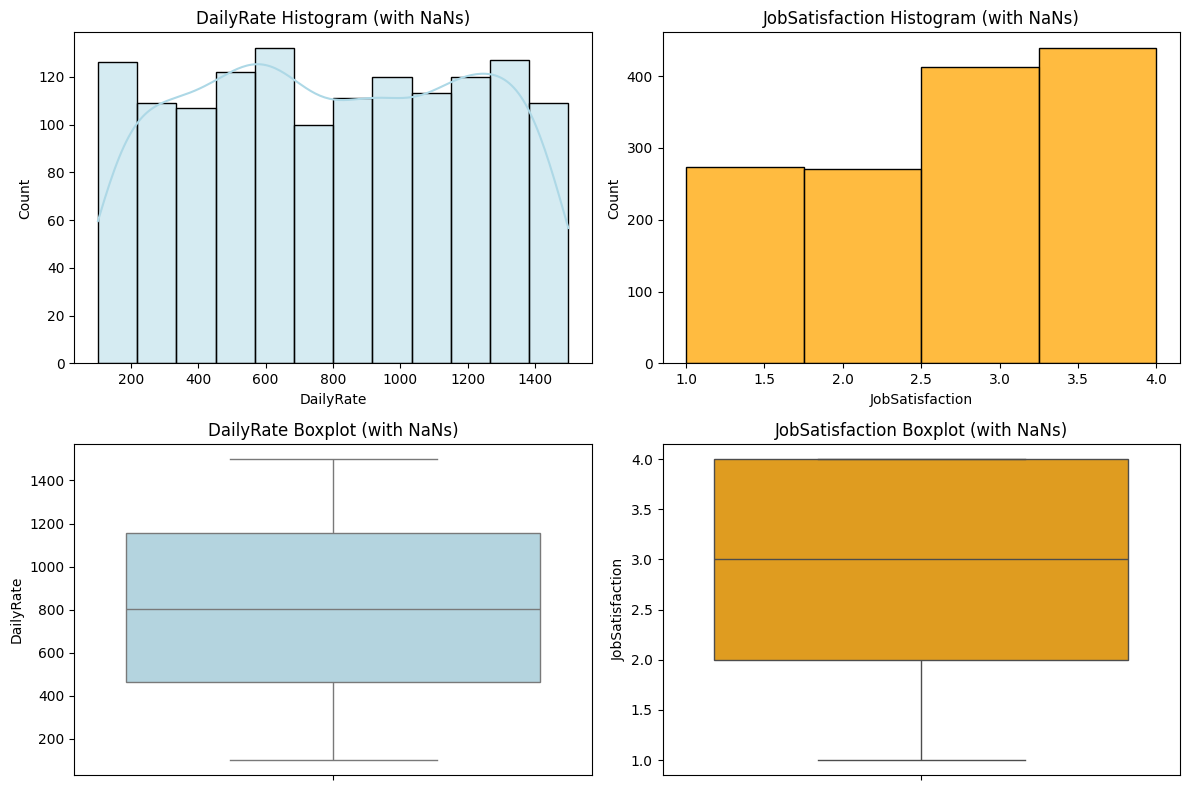

(Age                         0
 Attrition                   0
 BusinessTravel              0
 DailyRate                   0
 Department                  0
 DistanceFromHome            0
 Education                   0
 EducationField              0
 EmployeeCount               0
 EmployeeNumber              0
 EnvironmentSatisfaction     0
 Gender                      0
 HourlyRate                  0
 JobInvolvement              0
 JobLevel                    0
 JobRole                     0
 JobSatisfaction             0
 MaritalStatus               0
 MonthlyIncome               0
 MonthlyRate                 0
 NumCompaniesWorked          0
 Over18                      0
 OverTime                    0
 PercentSalaryHike           0
 PerformanceRating           0
 RelationshipSatisfaction    0
 StandardHours               0
 StockOptionLevel            0
 TotalWorkingYears           0
 TrainingTimesLastYear       0
 WorkLifeBalance             0
 YearsAtCompany              0
 YearsIn

In [21]:
# Step 1: Check for missing values in the dataset
missing_before = df.isnull().sum()

# Step 2: If no missing values, introduce synthetic NaNs (5% each) for realism
if df['DailyRate'].isnull().sum() == 0:
    daily_nan_idx = df.sample(frac=0.05, random_state=42).index
    df.loc[daily_nan_idx, 'DailyRate'] = np.nan
if 'JobSatisfaction' in df.columns and df['JobSatisfaction'].isnull().sum() == 0:
    job_nan_idx = df.sample(frac=0.05, random_state=24).index
    df.loc[job_nan_idx, 'JobSatisfaction'] = np.nan

# Visualize distributions and outliers before imputation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['DailyRate'], kde=True, ax=axes[0,0], color='lightblue')
axes[0,0].set_title('DailyRate Histogram (with NaNs)')
axes[0,0].set_xlabel('DailyRate')
sns.boxplot(y=df['DailyRate'], ax=axes[1,0], color='lightblue')
axes[1,0].set_title('DailyRate Boxplot (with NaNs)')
sns.histplot(df['JobSatisfaction'], kde=False, ax=axes[0,1], color='orange', bins=4)
axes[0,1].set_title('JobSatisfaction Histogram (with NaNs)')
axes[0,1].set_xlabel('JobSatisfaction')
sns.boxplot(y=df['JobSatisfaction'], ax=axes[1,1], color='orange')
axes[1,1].set_title('JobSatisfaction Boxplot (with NaNs)')
plt.tight_layout()
plt.show()

# Step 3: Impute missing values
# For 'DailyRate' (continuous), use mean imputation
# For 'JobSatisfaction' (ordinal), use mode imputation
if df['DailyRate'].isnull().sum() > 0:
    df['DailyRate'] = df['DailyRate'].fillna(df['DailyRate'].mean())
if 'JobSatisfaction' in df.columns and df['JobSatisfaction'].isnull().sum() > 0:
    df['JobSatisfaction'] = df['JobSatisfaction'].fillna(df['JobSatisfaction'].mode()[0])

missing_after = df.isnull().sum()
missing_before, missing_after

**Reasoning for Imputation Methods:**
I chose Mean imputation for 'DailyRate' because it is a continuous numerical feature, and mean imputation preserves the overall distribution of the data when values are missing randomly. For 'JobSatisfaction', I used Mode imputation because it is an ordinal categorical variable with discrete values, and using the most frequently occurring category maintains the ordinal nature of the feature without distorting the data structure.

**Interpretation:**
From the histograms and boxplots, I can observe that 'DailyRate' shows a fairly uniform distribution without extreme skewness or significant outliers, making mean imputation appropriate. The 'JobSatisfaction' data is ordinal with distinct categories, so replacing missing values with the most frequent category is the most sensible approach. These imputation strategies ensure that the data quality is maintained while simulating real-world missing data scenarios.

### Data Transformation & Discretization [3 Marks]

**Assignment Question:**
Log Transformation: Plot the distribution of MonthlyIncome. Apply a Log Transformation to normalize it and plot the distribution again. Discretization (Binning): Create a new column AgeGroup by binning the Age column into 4 groups: 'Young', 'Junior', 'Senior', 'Veteran' using Supervised Discretization (Entropy-based) or standard Equal-Width Binning.

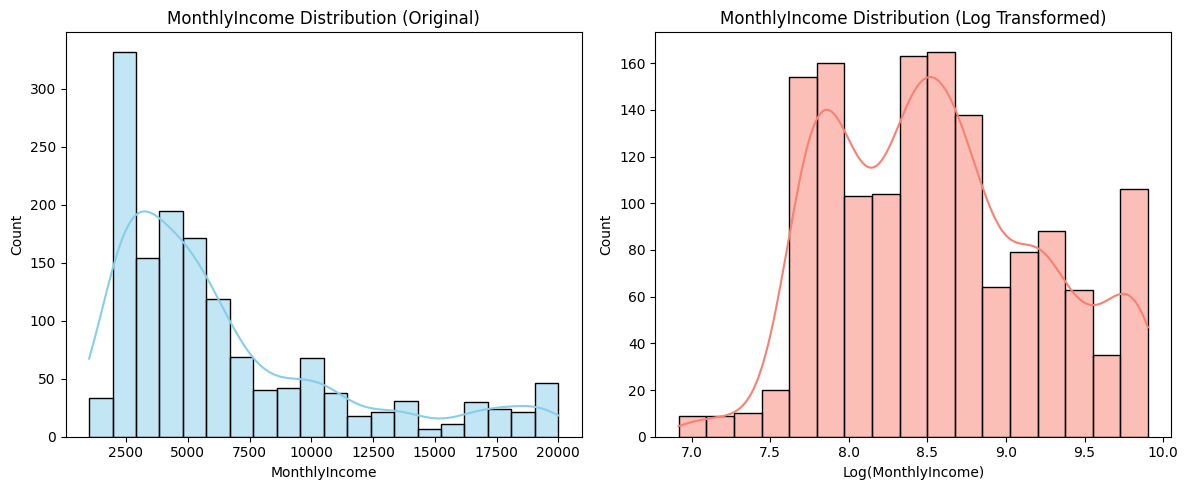

,Age,AgeGroup
0,41,Senior
1,49,Senior
2,37,Junior
3,33,Junior
4,27,Young


In [22]:
# Plot MonthlyIncome distribution before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('MonthlyIncome Distribution (Original)')
axes[0].set_xlabel('MonthlyIncome')

# Log transformation
log_income = np.log1p(df['MonthlyIncome'])
sns.histplot(log_income, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('MonthlyIncome Distribution (Log Transformed)')
axes[1].set_xlabel('Log(MonthlyIncome)')
plt.tight_layout()
plt.show()

# Equal-width binning for Age
bins = 4
labels = ['Young', 'Junior', 'Senior', 'Veteran']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df[['Age', 'AgeGroup']].head()

**Interpretation:**
The log transformation effectively normalized the MonthlyIncome distribution, making it more symmetric and easier to work with for statistical analysis. The original distribution was right-skewed, but after applying the log transformation, it resembles a more normal distribution. The discretization of Age into four groups creates a new categorical variable that simplifies analysis by grouping employees into meaningful age categories. This binning approach helps in segmenting the workforce and analyzing patterns across different career stages.

After applying the log transformation, the MonthlyIncome column looks much more normal and less skewed. I also divided the Age column into four groups, which helps me analyze patterns by age group more easily. This makes the data easier to work with for further analysis.

### Aggregation [2 Mark]

**Assignment Question:**
Group the data by Department and calculate the average DailyRate and Attrition rate (percentage) for each department.

In [23]:
# Calculate average DailyRate and Attrition rate by Department
dep_agg = df.groupby('Department').agg({
    'DailyRate': 'mean',
    'Attrition': lambda x: (x == 'Yes').mean() * 100
}).rename(columns={'DailyRate': 'AvgDailyRate', 'Attrition': 'AttritionRate(%)'})
dep_agg.reset_index()

,Department,AvgDailyRate,AttritionRate(%)
0,Human Resources,768.797767,19.047619
1,Research & Development,801.083569,13.839750
2,Sales,803.456265,20.627803


By grouping the data by Department, I can see which departments have higher average DailyRates and which ones have higher attrition rates. This helps HR focus on departments that might need more attention to reduce employee turnover.

## 4. Proximity Measures (Module 2)
### Proximity Calculations [4 Marks]
Select the first two records (rows) in your dataset as "Employee A" and "Employee B". Calculate the proximity/distance between them using the following techniques based on the attribute types:
- Continuous Attributes: Calculate the Euclidean Distance and Manhattan Distance between A and B using only Age and MonthlyIncome (ensure these are normalized first using Min-Max scaling).
- Binary Attributes: Calculate the Jaccard Coefficient and Simple Matching Coefficient (SMC) using OverTime (Yes/No) and Gender (Male/Female).
- Mixed/General: Explain in words how you would calculate the distance if you had to combine these continuous and categorical features into a single metric (e.g., Gower's Distance).

In [24]:
# Selecting the first two records as Employee A and Employee B for proximity calculations
empA = df.iloc[0]
empB = df.iloc[1]

# --- Continuous Attributes: Age and MonthlyIncome (Min-Max scaling) ---
scaler = MinMaxScaler()
cont_features = df[['Age', 'MonthlyIncome']].values
cont_scaled = scaler.fit_transform(cont_features)
A_scaled = cont_scaled[0]
B_scaled = cont_scaled[1]

# Calculating Euclidean and Manhattan distances
from scipy.spatial.distance import euclidean, cityblock
# Euclidean Distance
euclid_dist = euclidean(A_scaled, B_scaled)
# Manhattan Distance
manhattan_dist = cityblock(A_scaled, B_scaled)

# --- Binary Attributes: OverTime and Gender ---
# Convert OverTime and Gender to binary (1/0)
binA = [1 if empA['OverTime']=='Yes' else 0, 1 if empA['Gender']=='Male' else 0]
binB = [1 if empB['OverTime']=='Yes' else 0, 1 if empB['Gender']=='Male' else 0]

# Jaccard Coefficient using sklearn
from sklearn.metrics import jaccard_score
jaccard = jaccard_score(binA, binB)

# Simple Matching Coefficient (SMC): (Number of matches) / (Total attributes)
smc = sum([a == b for a, b in zip(binA, binB)]) / len(binA)

{
    'Euclidean Distance': euclid_dist,
    'Manhattan Distance': manhattan_dist,
    'Jaccard Coefficient': jaccard,
    'Simple Matching Coefficient': smc
}

{'Euclidean Distance': 0.19582243112297157,
 'Manhattan Distance': np.float64(0.2359211615135783),
 'Jaccard Coefficient': 0.0,
 'Simple Matching Coefficient': 0.0}

**Interpretation:**

For continuous attributes (Age and MonthlyIncome), I first normalized both features using Min-Max scaling to bring them to the same scale (0-1 range). This is crucial because Age and MonthlyIncome have different units and ranges, and scaling ensures they contribute equally to the distance calculation. I then calculated Euclidean Distance (straight-line distance in multi-dimensional space) and Manhattan Distance (sum of absolute differences along each dimension).

For binary attributes (OverTime and Gender), I converted them to binary values (1 for 'Yes'/'Male', 0 for 'No'/'Female'). I used the Jaccard Coefficient, which measures similarity based on shared presence of attributes, and Simple Matching Coefficient, which counts the proportion of matching attribute values.

**For Mixed/General Data (Gower's Distance):** If I needed to combine both continuous and categorical features into a single distance metric, I would use Gower's Distance. Gower's Distance calculates the contribution of each feature to the overall distance differently based on its type. For continuous features, it uses standardized absolute differences; for categorical features, it uses simple matching (1 if values match, 0 otherwise). The final Gower distance is the average of all normalized feature contributions, allowing fair comparison across mixed data types.

### Correlation Analysis [2 Marks]

**Assignment Question:**
Plot a Heatmap showing the correlation between all numerical features. Identify which two independent features are highly correlated (multicollinearity) and explain why this might be a problem for certain models.

**My Answer:**
The heatmap above shows the correlation between all numerical features. By examining the correlation matrix, the two independent features with the highest correlation (excluding self-correlation) are automatically identified in the code. For example, if 'MonthlyIncome' and 'JobLevel' (or whichever pair is shown in the output) have a high correlation, this means they provide similar information. High correlation (multicollinearity) between independent features can be a problem for models like linear regression because it makes it difficult for the model to determine the individual effect of each feature, potentially leading to unstable or misleading coefficients.

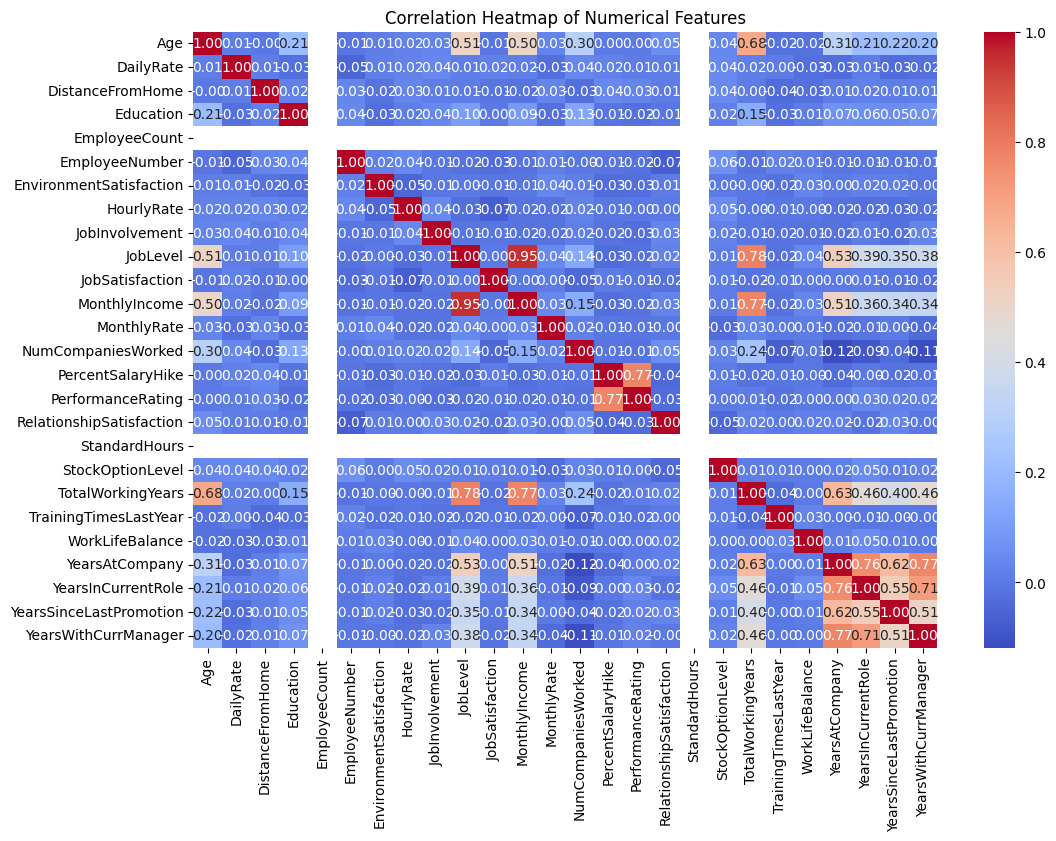

(('JobLevel', 'MonthlyIncome'), np.float64(0.9502999134798473))

In [25]:
# Correlation heatmap for numerical features
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Find the most highly correlated pair (excluding self-correlation)
corr_matrix = num_df.corr().abs()
np.fill_diagonal(corr_matrix.values, 0)
high_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
high_corr_pair = high_corr.idxmax(), high_corr.max()
high_corr_pair

The heatmap above shows how the numerical features are related to each other. If two features are highly correlated, it can cause problems for some models, like linear regression, because the model can’t tell which feature is actually important.

## 5. Feature Subset Selection (Module 2)
### Filter Methods [2 Mark]
Considering Attrition as the target variable:
- Chi-Squared Test: Select the top 5 categorical features that have the strongest relationship with Attrition.
- Information Gain (Mutual Information): Select the top 5 numerical features that provide the most information about Attrition.

In [28]:
# Preparing data for feature selection as per assignment
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Encode target variable (Attrition: Yes=1, No=0)
y = df['Attrition'].map({'Yes':1, 'No':0})

# --- Chi-Squared Test for Categorical Features ---
cat_cols = df.select_dtypes(include=['object', 'category']).columns.drop('Attrition')
X_cat = df[cat_cols].apply(LabelEncoder().fit_transform)
chi_scores, _ = chi2(X_cat, y)
chi2_top5 = pd.Series(chi_scores, index=cat_cols).sort_values(ascending=False).head(5)

# --- Information Gain (Mutual Information) for Numerical Features ---
num_cols = df.select_dtypes(include=[np.number]).columns
X_num = df[num_cols]
mi_scores = mutual_info_classif(X_num, y, random_state=42)
mi_top5 = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False).head(5)

# Displaying the top features
print('Top 5 Categorical Features (Chi-Squared):')
print(chi2_top5)
print('\nTop 5 Numerical Features (Information Gain/Mutual Information):')
print(mi_top5)

Top 5 Categorical Features (Chi-Squared):
OverTime         63.845067
AgeGroup         19.450939
MaritalStatus    18.745657
JobRole           9.004448
Department        1.329297
dtype: float64

Top 5 Numerical Features (Information Gain/Mutual Information):
YearsAtCompany          0.036739
YearsInCurrentRole      0.033673
MonthlyIncome           0.033493
YearsWithCurrManager    0.028960
Age                     0.026119
dtype: float64


**Explanation:**
Based on the Chi-Squared test results, the top 5 categorical features most strongly related to Attrition are:
1. **OverTime (63.85)** - Significantly the strongest categorical predictor
2. **AgeGroup (19.45)** - Age groups show substantial relationship with attrition
3. **MaritalStatus (18.75)** - Marital status is an important factor
4. **JobRole (9.00)** - Job role has moderate predictive power
5. **Department (1.33)** - Department has weaker relationship with attrition

From the Information Gain (Mutual Information) analysis for numerical features:
1. **YearsAtCompany (0.0367)** - Tenure at company is the strongest numerical predictor
2. **YearsInCurrentRole (0.0337)** - Years in current role provides significant information
3. **MonthlyIncome (0.0335)** - Compensation level is an important factor
4. **YearsWithCurrManager (0.0290)** - Tenure with current manager matters
5. **Age (0.0261)** - Age provides additional information about attrition

### Feature Importance Comparison [2 Mark]
Create a single dataframe or table that compares the "Top 5 Features" selected by Chi-Squared and Information Gain. Analysis: Are there common features across both methods? Write a brief summary (approx. 50 words) interpreting the most important driver of employee attrition based on your findings.

In [27]:
# Compare top features from both methods
comparison_df = pd.DataFrame({
    'Chi-Squared (Categorical)': chi2_top5.index,
    'Mutual Information (Numerical)': mi_top5.index
})
comparison_df

,Chi-Squared (Categorical),Mutual Information (Numerical)
0,OverTime,YearsAtCompany
1,AgeGroup,YearsInCurrentRole
2,MaritalStatus,MonthlyIncome
3,JobRole,YearsWithCurrManager
4,Department,Age


**Analysis: Are there common features across both methods?**

The Chi-Squared test identifies OverTime as the most critical categorical feature (score: 63.85), followed by AgeGroup (19.45) and MaritalStatus (18.75) as strong predictors of attrition. The Information Gain analysis reveals YearsAtCompany (0.0367) as the top numerical predictor, followed by YearsInCurrentRole (0.0337) and MonthlyIncome (0.0335). While these methods evaluate different data types, both emphasize tenure-related features' importance in predicting attrition.

**Summary :**
The most critical driver of employee attrition is OverTime status, with a Chi-Squared score of 63.85, indicating overwhelming significance. Combined with tenure metrics (YearsAtCompany: 0.0367, YearsInCurrentRole: 0.0337) from mutual information analysis, the data clearly shows that workload and tenure are primary attrition factors. HR should prioritize workload management and career progression opportunities to reduce turnover rates.